In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate the data

In [3]:
SEED = 1234
NUM_SAMPLES = 50

In [4]:
np.random.seed(SEED)

In [40]:
# Generate synthetic data
def generate_data(num_samples):
    """Generate dummy data for linear regression."""
    X = np.array(range(num_samples))
    random_noise = np.random.uniform(-10, 20, size=num_samples)
    y = 3.5*X + random_noise # add some noise
    return X, y

In [58]:
# Generate random data
X, y = generate_data(num_samples=NUM_SAMPLES)
data = np.column_stack((X, y))
print(f"Data Sample: \n{data[:5]}")

Data Sample: 
[[ 0.          8.31228359]
 [ 1.          7.36051512]
 [ 2.         17.26420149]
 [ 3.         27.23434664]
 [ 4.          6.15411997]]


In [61]:
# Load into a Pandas DataFrame
df = pd.DataFrame(data, columns=["X", "y"])
df.head()

,X,y
0,0.0,8.312284
1,1.0,7.360515
2,2.0,17.264201
3,3.0,27.234347
4,4.0,6.154120


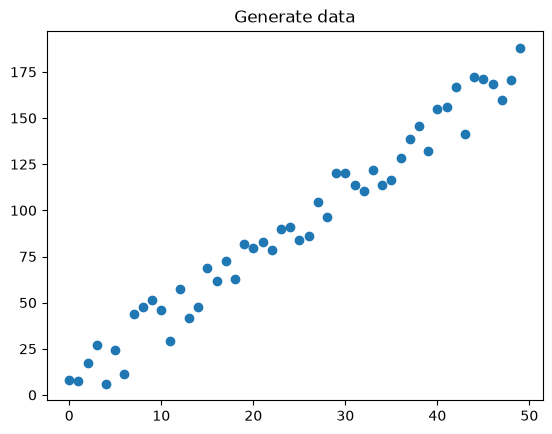

In [62]:
# Scatter plot
plt.title("Generate data")
plt.scatter(x=df["X"], y=df["y"])
plt.show();

# 2. Split data 

The data should be split into `train_set` and `test_set`.

In [63]:
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

In [64]:
# Shuffle data
indices = list(range(NUM_SAMPLES))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]
# print(indices)
print(f"X shape: {X.shape} | y shape: {y.shape}")

X shape: (50,) | y shape: (50,)


In [65]:
# Split indices
train_start = 0
train_end = int(TRAIN_SIZE * NUM_SAMPLES)
val_start = train_end
val_end = int((TRAIN_SIZE + VAL_SIZE) * NUM_SAMPLES)
test_start = val_end

In [66]:
X_train = X[train_start:train_end]
y_train = y[train_start:train_end]
X_val = X[val_start:val_end]
y_val = y[val_start:val_end]
X_test = X[test_start:]
y_test = y[test_start:]
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (35,), y_train: (35,)
X_val: (7,), y_val: (7,)
X_test: (8,), y_test: (8,)


# 3. Standardize data

We need to standardize our data (zero mean and unit variance) so a specific feature magnitude doesn't effect how the model learns its weights

In [67]:
def standardize_data(data, mean, std):
    return (mean - data) / std

In [68]:
X_mean = np.mean(X_train)
X_std = np.std(X_train)
y_mean = np.mean(y_train)
y_std = np.std(y_train)

In [69]:
X_train = standardize_data(X_train, X_mean, X_std)
y_train = standardize_data(y_train, y_mean, y_std)
X_val = standardize_data(X_val, X_mean, X_std)
y_val = standardize_data(y_val, y_mean, y_std)
X_test = standardize_data(X_test, X_mean, X_std)
y_test = standardize_data(y_test, y_mean, y_std)

In [70]:
X_test.shape

(8,)

In [71]:
print (f"mean: {np.mean(X_test):.1f}, std: {np.std(X_test):.1f}")
print (f"mean: {np.mean(y_test):.1f}, std: {np.std(y_test):.1f}")

mean: -0.1, std: 1.0
mean: -0.3, std: 1.0


# 4. Weight

In [72]:
# Step 1: Randomly intialize the model's weight

INPUT_DIM = 1
OUTPUT_DIM = 1

In [76]:
# intialize random weight

W = 0.01
b = 0.2


# 5. Model

In [77]:
# Forward Pass
y_pred = np.dot(X_train, W) + b

print(f"y_pred: {y_pred.shape}")

y_pred: (35,)
